In [1]:
import pandas as pd
import pydeseq2
from pydeseq2.dds import DeseqDataSet

In [2]:
counts = pd.read_csv("../data/GSE95640_raw_counts_GRCh38.p13_NCBI.tsv", sep="\t")  
counts = counts.set_index("GeneID") 
counts

,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,30,2,11,1,4,17,4,2,11,3,...,1,9,9,6,6,5,3,3,5,6
653635,819,428,686,203,531,450,459,422,929,370,...,301,670,502,404,367,528,377,321,142,742
102466751,19,10,22,5,17,12,14,15,29,12,...,8,29,20,9,13,29,6,9,5,20
107985730,1,0,1,0,1,1,0,1,1,1,...,0,1,1,2,1,1,0,1,1,1
100302278,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,93147,47296,99571,49725,78416,85823,89808,86901,185626,101525,...,107472,114349,129594,152116,120091,196380,130797,132109,73240,89802
4556,7145,3117,8110,3933,6553,6552,6842,6012,13738,8695,...,8234,8607,10276,10647,8644,13381,8627,9907,4428,8074
4519,254187,147544,260850,135703,181326,247336,244981,248633,459480,326775,...,233990,404258,315260,368103,287457,474351,298329,332767,200893,265800


In [3]:
file_path = "../data/GSE95640_series_matrix.txt"
df_sample_annot = pd.read_csv(file_path, sep="\t", skiprows=48, nrows=(92 - 48), index_col=0, header=0)
df_sample_annot = df_sample_annot.iloc[[0, 11], :].T
df_sample_annot.columns=['sample_name', 'group'] 

df_sample_annot["group_0_1"] = df_sample_annot["group"].apply(
    lambda x: 0 if "baseline without LCD" in x else 1
)

df_sample_annot

,sample_name,group,group_0_1
B00EVBV,GSM2520157,time: CID1 is for the baseline without LCD,0
B00EVBY,GSM2520158,time: CID1 is for the baseline without LCD,0
B00EVC0,GSM2520159,time: CID1 is for the baseline without LCD,0
B00EVC2,GSM2520160,time: CID1 is for the baseline without LCD,0
B00EVC4,GSM2520161,time: CID1 is for the baseline without LCD,0
...,...,...,...
B00EWA9,GSM2520534,time: CID2 is after 8 weeks of LCD,1
B00EWAE,GSM2520535,time: CID2 is after 8 weeks of LCD,1
B00EWAF,GSM2520536,time: CID2 is after 8 weeks of LCD,1
B00EWEV,GSM2520537,time: CID1 is for the baseline without LCD,0


In [4]:
df_gene_annot = pd.read_csv('../data/Human.GRCh38.p13.annot.tsv', sep='\t', index_col = None, header=0, low_memory=False)
df_gene_annot

,GeneID,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39371,4541,ND6,NADH dehydrogenase subunit 6,MTND6,protein-coding,NaN,active,NC_012920.1,14149,14673,negative,525,GO:0008137,GO:0006120///GO:0009060///GO:0032981///GO:0035...,GO:0005739///GO:0005743///GO:0005747,NADH dehydrogenase (ubiquinone) activity,"mitochondrial electron transport, NADH to ubiq...",mitochondrion///mitochondrial inner membrane//...
39372,4556,TRNE,tRNA-Glu,MTTE,tRNA,NaN,active,NC_012920.1,14674,14742,negative,69,NaN,NaN,NaN,NaN,NaN,NaN
39373,4519,CYTB,cytochrome b,MTCYB,protein-coding,NaN,active,NC_012920.1,14747,15887,positive,1141,GO:0008121///GO:0046872,GO:0006122///GO:0045333///GO:1902600,GO:0005739///GO:0005743///GO:0005750///GO:0016020,ubiquinol-cytochrome-c reductase activity///me...,"mitochondrial electron transport, ubiquinol to...",mitochondrion///mitochondrial inner membrane//...
39374,4576,TRNT,tRNA-Thr,MTTT,tRNA,NaN,active,NC_012920.1,15888,15953,positive,66,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_sample_annot[['sample_name', 'group_0_1']]

,sample_name,group_0_1
B00EVBV,GSM2520157,0
B00EVBY,GSM2520158,0
B00EVC0,GSM2520159,0
B00EVC2,GSM2520160,0
B00EVC4,GSM2520161,0
...,...,...
B00EWA9,GSM2520534,1
B00EWAE,GSM2520535,1
B00EWAF,GSM2520536,1
B00EWEV,GSM2520537,0


In [6]:
# ensure categorical labels
metadata = df_sample_annot[['sample_name','group_0_1']].copy()
metadata = metadata.set_index('sample_name').rename(columns={'group_0_1':'condition'})
metadata['condition'] = metadata['condition'].map({0:'baseline', 1:'lcd'}).astype('category')
metadata = metadata.loc[counts.columns]

# DESeq2 fit
dds = DeseqDataSet(counts=counts.T, metadata=metadata, design_factors="condition")
dds.deseq2()

# fetch normalized counts (robust to API variants); fall back to size-factor scaling
norm_mat = None
for attr in ("normed_counts", "normalized_counts", "norm_counts"):
    if hasattr(dds, attr):
        norm_mat = getattr(dds, attr)
        break
if norm_mat is None:
    if hasattr(dds, "size_factors"):
        sf = pd.Series(dds.size_factors, index=metadata.index)
    elif hasattr(dds, "obs") and "size_factors" in dds.obs.columns:
        sf = dds.obs["size_factors"]
    elif hasattr(dds, "obsm") and "size_factors" in dds.obsm:
        sf = pd.Series(dds.obsm["size_factors"], index=metadata.index)
    else:
        raise AttributeError("Could not locate size factors or normalized counts on dds.")
    norm_mat = counts.T.div(sf, axis=0)  # samples x genes

norm_counts = norm_mat.T  # genes x samples
norm_counts


/Users/jim/anaconda3/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/pr/qsqt558j4r78hx4z6m7cdd9r0000gn/T/ipykernel_30829/3892074670.py:8: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts.T, metadata=metadata, design_factors="condition")
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.29 seconds.

Fitting dispersions...
... done in 2.30 seconds.

Fitting dispersion trend curve...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 3.10 seconds.

Fitting LFCs...
... done in 1.65 seconds.

Calculating cook's distance...
... done in 0.62 seconds.

Replacing 289 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.08 seconds.

Fitting LFCs...
... done in 0.03 seconds.



,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,21.005022,2.253288,9.606387,1.787645,2.985084,18.561131,4.279128,1.987068,7.709543,2.399610,...,1.001034,6.444927,6.151350,4.607232,5.725350,4.194643,2.588963,2.837753,7.136887,4.514742
653635,573.437111,482.203642,599.089232,362.891850,396.269921,491.324046,491.029974,419.271322,651.105935,295.951870,...,301.311342,479.789033,343.108653,310.220309,350.200585,442.954275,325.346371,303.639540,202.687600,558.323045
102466751,13.303181,11.266440,19.212774,8.938223,12.686608,13.101975,14.976949,14.903009,20.325158,9.598439,...,8.008275,20.766988,13.669667,6.910848,12.404925,24.328928,5.177926,8.513258,7.136887,15.049139
107985730,0.700167,0.000000,0.873308,0.000000,0.746271,1.091831,0.000000,0.993534,0.700868,0.799870,...,0.000000,0.716103,0.683483,1.535744,0.954225,0.838929,0.000000,0.945918,1.427377,0.752457
100302278,0.000000,0.000000,0.873308,0.000000,0.000000,0.000000,0.000000,0.000000,0.700868,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.945918,1.427377,0.752457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,65218.493984,53285.755684,86956.142713,88890.626715,58519.589752,93704.230291,96074.988846,86339.092872,130099.236104,81206.793640,...,107583.164659,81885.665935,88575.344297,116805.625222,114593.837604,164748.788991,112876.205083,124964.224368,104541.125575,67572.137611
4556,5002.696163,3511.749418,7082.527216,7030.806131,4890.314115,7153.678115,7319.448977,5973.126044,9628.518126,6954.868955,...,8242.516914,6163.498821,7023.475145,8175.533749,8248.321125,11225.702951,7444.995078,9371.205374,6320.427417,6075.337287
4519,177973.454113,166229.565643,227802.370435,242588.732369,135318.342320,270049.165182,262076.283209,247025.323967,322034.612635,261377.493147,...,234232.029724,289490.380672,215474.968310,282656.006345,274298.663315,397946.597448,257454.264135,314770.152301,286750.141182,200003.053127


In [7]:
import warnings
from anndata._core.aligned_mapping import ImplicitModificationWarning

warnings.filterwarnings("ignore", category=ImplicitModificationWarning)

metadata = df_sample_annot[['sample_name','group_0_1']].copy()
metadata = metadata.set_index('sample_name').rename(columns={'group_0_1':'condition'})
metadata['condition'] = metadata['condition'].map({0:'baseline', 1:'lcd'}).astype('category')
metadata = metadata.loc[counts.columns]

counts.index = counts.index.astype(str)
counts.columns = counts.columns.astype(str)
metadata.index = metadata.index.astype(str)

dds = DeseqDataSet(counts=counts.T, metadata=metadata, design="~ condition")
dds.deseq2()

norm_mat = None
for attr in ("normed_counts", "normalized_counts", "norm_counts"):
    if hasattr(dds, attr):
        norm_mat = getattr(dds, attr)
        break
if norm_mat is None:
    sf = (
        pd.Series(dds.size_factors, index=metadata.index)
        if hasattr(dds, "size_factors")
        else (dds.obs["size_factors"] if ("obs" in dir(dds) and "size_factors" in dds.obs.columns) else
              pd.Series(dds.obsm["size_factors"], index=metadata.index))
    )
    norm_mat = counts.T.div(sf, axis=0)

norm_counts = norm_mat.T
norm_counts


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.28 seconds.

Fitting dispersions...
... done in 2.13 seconds.

Fitting dispersion trend curve...
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 3.16 seconds.

Fitting LFCs...
... done in 1.70 seconds.

Calculating cook's distance...
... done in 0.59 seconds.

Replacing 289 outlier genes.

Fitting dispersions...
... done in 0.11 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.04 seconds.



,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,21.005022,2.253288,9.606387,1.787645,2.985084,18.561131,4.279128,1.987068,7.709543,2.399610,...,1.001034,6.444927,6.151350,4.607232,5.725350,4.194643,2.588963,2.837753,7.136887,4.514742
653635,573.437111,482.203642,599.089232,362.891850,396.269921,491.324046,491.029974,419.271322,651.105935,295.951870,...,301.311342,479.789033,343.108653,310.220309,350.200585,442.954275,325.346371,303.639540,202.687600,558.323045
102466751,13.303181,11.266440,19.212774,8.938223,12.686608,13.101975,14.976949,14.903009,20.325158,9.598439,...,8.008275,20.766988,13.669667,6.910848,12.404925,24.328928,5.177926,8.513258,7.136887,15.049139
107985730,0.700167,0.000000,0.873308,0.000000,0.746271,1.091831,0.000000,0.993534,0.700868,0.799870,...,0.000000,0.716103,0.683483,1.535744,0.954225,0.838929,0.000000,0.945918,1.427377,0.752457
100302278,0.000000,0.000000,0.873308,0.000000,0.000000,0.000000,0.000000,0.000000,0.700868,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.945918,1.427377,0.752457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,65218.493984,53285.755684,86956.142713,88890.626715,58519.589752,93704.230291,96074.988846,86339.092872,130099.236104,81206.793640,...,107583.164659,81885.665935,88575.344297,116805.625222,114593.837604,164748.788991,112876.205083,124964.224368,104541.125575,67572.137611
4556,5002.696163,3511.749418,7082.527216,7030.806131,4890.314115,7153.678115,7319.448977,5973.126044,9628.518126,6954.868955,...,8242.516914,6163.498821,7023.475145,8175.533749,8248.321125,11225.702951,7444.995078,9371.205374,6320.427417,6075.337287
4519,177973.454113,166229.565643,227802.370435,242588.732369,135318.342320,270049.165182,262076.283209,247025.323967,322034.612635,261377.493147,...,234232.029724,289490.380672,215474.968310,282656.006345,274298.663315,397946.597448,257454.264135,314770.152301,286750.141182,200003.053127


In [8]:
from pydeseq2.ds import DeseqStats

stat_res = DeseqStats(dds, contrast=["condition", "lcd", "baseline"])
stat_res.summary()

res = stat_res.results_df  # complete DESeq2 results, no filtering applied
# res.to_csv("../data/GSE95640_DE_full_lcd_vs_baseline.csv")
res


Running Wald tests...


Log2 fold change & Wald test p-value: condition lcd vs baseline
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
GeneID                                                                       
100287102       6.590313       -0.202534  0.098431 -2.057620  3.962665e-02   
653635        343.981129        0.061672  0.050887  1.211940  2.255353e-01   
102466751      10.153971        0.198281  0.066937  2.962194  3.054551e-03   
107985730       0.556161       -0.342628  0.196990 -1.739313  8.197966e-02   
100302278       0.170948       -0.239804  0.406655 -0.589699  5.553928e-01   
...                  ...             ...       ...       ...           ...   
4541        96337.678069       -0.156819  0.049512 -3.167293  1.538650e-03   
4556         7639.404756       -0.246593  0.047154 -5.229574  1.699011e-07   
4519       266250.329021       -0.257960  0.052772 -4.888171  1.017773e-06   
4576          700.797236       -0.329577  0.060019 -5.491235  3.991319e-08   


... done in 0.84 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GeneID,,,,,,
100287102,6.590313,-0.202534,0.098431,-2.057620,3.962665e-02,9.918603e-02
653635,343.981129,0.061672,0.050887,1.211940,2.255353e-01,3.761005e-01
102466751,10.153971,0.198281,0.066937,2.962194,3.054551e-03,1.198571e-02
107985730,0.556161,-0.342628,0.196990,-1.739313,8.197966e-02,1.747067e-01
100302278,0.170948,-0.239804,0.406655,-0.589699,5.553928e-01,NaN
...,...,...,...,...,...,...
4541,96337.678069,-0.156819,0.049512,-3.167293,1.538650e-03,6.708814e-03
4556,7639.404756,-0.246593,0.047154,-5.229574,1.699011e-07,2.227032e-06
4519,266250.329021,-0.257960,0.052772,-4.888171,1.017773e-06,1.101766e-05


In [9]:
filtered_res = res[(res.padj < 0.05) & ((res.log2FoldChange > 1) | (res.log2FoldChange < -1))]
filtered_res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GeneID,,,,,,
126767,16.616191,-1.743579,0.160859,-10.839206,2.244108e-27,6.617426e-25
93190,1.280361,-1.351638,0.208506,-6.482490,9.022108e-11,2.331673e-09
105378632,1.935713,-1.192233,0.163587,-7.288058,3.144538e-13,1.291450e-11
1301,174.357525,-1.392666,0.154917,-8.989744,2.478059e-19,2.297893e-17
79679,0.540909,1.062292,0.305869,3.473023,5.146319e-04,2.626877e-03
...,...,...,...,...,...,...
286411,142.467844,-1.222210,0.082193,-14.870026,5.159346e-50,2.173411e-46
728695,0.714062,-1.833775,0.267881,-6.845473,7.622342e-12,2.373470e-10
266,0.877885,-1.388530,0.355229,-3.908833,9.274298e-05,5.972494e-04


In [10]:
# 1) Normalize IDs on BOTH sides to the same clean string form
#    - cast to str
#    - strip spaces
#    - drop trailing ".0" if present

df_gene_annot = df_gene_annot.copy()
df_gene_annot["GeneID_norm"] = (
    df_gene_annot["GeneID"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

filtered_res = filtered_res.copy()
filtered_res.index = (
    filtered_res.index
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# 2) Build mapping and insert as first column
gene_map = df_gene_annot.set_index("GeneID_norm")["Symbol"]
filtered_res.insert(0, "gene_symbol", filtered_res.index.map(gene_map))

# (Optional) quick sanity check: how many unmatched?
unmatched = filtered_res["gene_symbol"].isna().sum()
print(f"Unmatched gene IDs: {unmatched} / {len(filtered_res)}")

# (Optional) if you also want Description:
# desc_map = df_gene_annot.set_index("GeneID_norm")["Description"]
# filtered_res.insert(1, "description", filtered_res.index.map(desc_map))
filtered_res


Unmatched gene IDs: 0 / 177


,gene_symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GeneID,,,,,,,
126767,AADACL3,16.616191,-1.743579,0.160859,-10.839206,2.244108e-27,6.617426e-25
93190,CFAP107,1.280361,-1.351638,0.208506,-6.482490,9.022108e-11,2.331673e-09
105378632,LOC105378632,1.935713,-1.192233,0.163587,-7.288058,3.144538e-13,1.291450e-11
1301,COL11A1,174.357525,-1.392666,0.154917,-8.989744,2.478059e-19,2.297893e-17
79679,VTCN1,0.540909,1.062292,0.305869,3.473023,5.146319e-04,2.626877e-03
...,...,...,...,...,...,...,...
286411,LINC00632,142.467844,-1.222210,0.082193,-14.870026,5.159346e-50,2.173411e-46
728695,SPANXB1,0.714062,-1.833775,0.267881,-6.845473,7.622342e-12,2.373470e-10
266,AMELY,0.877885,-1.388530,0.355229,-3.908833,9.274298e-05,5.972494e-04


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# gene list from filtered_res, normalized like before
genes = (
    pd.Index(filtered_res.index)
    .astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
)

# align norm_counts gene index the same way
norm_counts_use = norm_counts.copy()
norm_counts_use.index = (
    norm_counts_use.index.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
)

# intersect and subset to filtered genes only
genes = genes.intersection(norm_counts_use.index)
X = norm_counts_use.loc[genes].T  # samples x genes

# labels
y = metadata.loc[X.index, "condition"]

# optional: guard against any non-finite values
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# split, train, report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    baseline       0.82      0.85      0.84        39
         lcd       0.84      0.82      0.83        38

    accuracy                           0.83        77
   macro avg       0.83      0.83      0.83        77
weighted avg       0.83      0.83      0.83        77



              precision    recall  f1-score   support

    baseline       0.82      0.85      0.84        39
         lcd       0.84      0.82      0.83        38

    accuracy                           0.83        77
   macro avg       0.83      0.83      0.83        77
weighted avg       0.83      0.83      0.83        77

AUC (test): 0.913
AUC bootstrap mean ± 1 SD: 0.913 ± 0.032


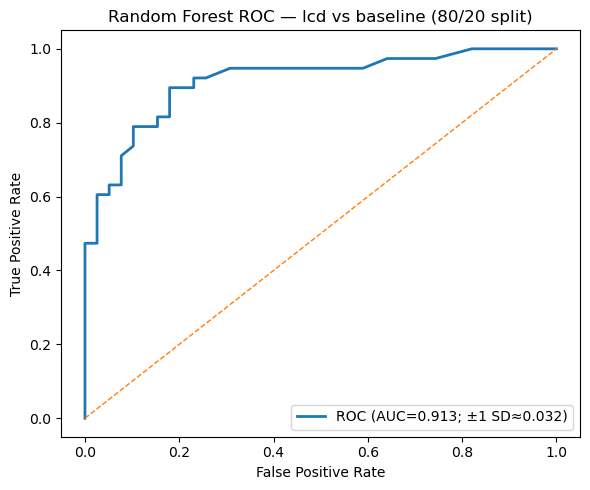

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# ---- features: only filtered genes ----
genes = (
    pd.Index(filtered_res.index)
    .astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
)
norm_counts_use = norm_counts.copy()
norm_counts_use.index = (
    norm_counts_use.index.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
)
genes = genes.intersection(norm_counts_use.index)
X = norm_counts_use.loc[genes].T  # samples x genes

# ---- labels ----
y = metadata.loc[X.index, "condition"]  # expect labels "baseline" and "lcd"
pos_label = "lcd"

# ---- 80/20 split, train RF ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ---- predictions & classification report ----
y_proba = rf.predict_proba(X_test)[:, list(rf.classes_).index(pos_label)]
y_pred  = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# ---- ROC + AUC on test set ----
fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=pos_label)
auc_point = roc_auc_score(y_test, y_proba)

# ---- Bootstrap AUC SD on the test set ----
rng = np.random.default_rng(42)
n = len(y_test)
y_test_arr = y_test.to_numpy()
proba_arr  = y_proba
B = 1000
aucs = np.empty(B)
idx = np.arange(n)
for b in range(B):
    boot = rng.choice(idx, size=n, replace=True)
    aucs[b] = roc_auc_score(y_test_arr[boot], proba_arr[boot])
auc_mean = aucs.mean()
auc_std  = aucs.std(ddof=1)

print(f"AUC (test): {auc_point:.3f}")
print(f"AUC bootstrap mean ± 1 SD: {auc_mean:.3f} ± {auc_std:.3f}")

# ---- Plot ROC curve ----
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={auc_point:.3f}; ±1 SD≈{auc_std:.3f})")
plt.plot([0,1], [0,1], lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC — lcd vs baseline (80/20 split)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

    baseline       0.82      0.85      0.84        39
         lcd       0.84      0.82      0.83        38

    accuracy                           0.83        77
   macro avg       0.83      0.83      0.83        77
weighted avg       0.83      0.83      0.83        77



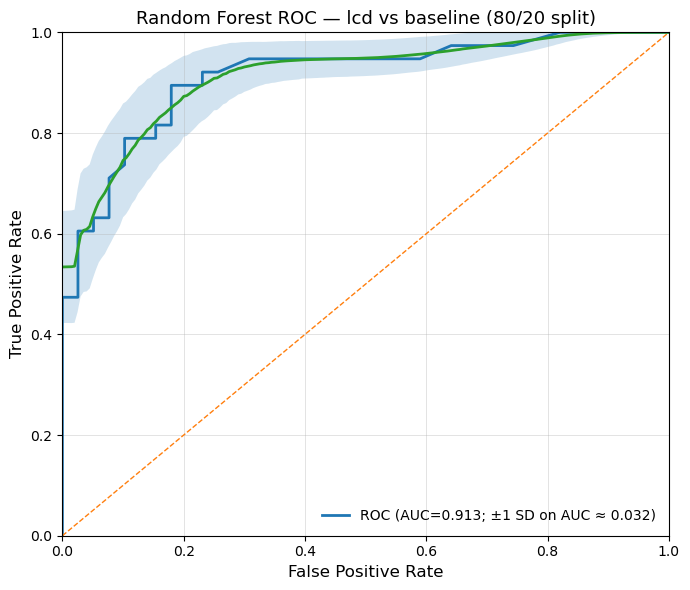

In [13]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- features: only filtered genes ---
genes = (
    pd.Index(filtered_res.index)
    .astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
)
norm_counts_use = norm_counts.copy()
norm_counts_use.index = (
    norm_counts_use.index.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
)
genes = genes.intersection(norm_counts_use.index)
X = norm_counts_use.loc[genes].T  # samples x genes

# --- labels ---
y = metadata.loc[X.index, "condition"]
pos_label = "lcd"

# --- split & train ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# --- predictions ---
y_proba = rf.predict_proba(X_test)[:, list(rf.classes_).index(pos_label)]
y_pred  = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# --- point ROC/AUC on test split ---
fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=pos_label)
auc_point = roc_auc_score(y_test, y_proba)

# --- bootstrap ROC band (±1 SD) and AUC SD ---
rng = np.random.default_rng(42)
y_test_arr = y_test.to_numpy()
proba_arr  = y_proba
n = len(y_test_arr)
B = 1000

# fixed FPR grid for mean/stdev band
fpr_grid = np.linspace(0, 1, 201)
tpr_boot = np.empty((B, fpr_grid.size))
auc_boot = np.empty(B)

idx = np.arange(n)
for b in range(B):
    boot = rng.choice(idx, size=n, replace=True)
    auc_boot[b] = roc_auc_score(y_test_arr[boot], proba_arr[boot])
    fpr_b, tpr_b, _ = roc_curve(y_test_arr[boot], proba_arr[boot], pos_label=pos_label)
    # interpolate TPR on fixed grid
    tpr_boot[b] = np.interp(fpr_grid, fpr_b, tpr_b)

tpr_mean = tpr_boot.mean(axis=0)
tpr_std  = tpr_boot.std(axis=0, ddof=1)
tpr_low  = np.clip(tpr_mean - tpr_std, 0, 1)
tpr_high = np.clip(tpr_mean + tpr_std, 0, 1)

auc_mean = auc_boot.mean()
auc_sd   = auc_boot.std(ddof=1)

# --- pretty Matplotlib plot (no seaborn) ---
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={auc_point:.3f}; ±1 SD on AUC ≈ {auc_sd:.3f})")
plt.plot([0,1], [0,1], linestyle="--", lw=1)

# mean ROC + ±1 SD band
plt.plot(fpr_grid, tpr_mean, lw=2)
plt.fill_between(fpr_grid, tpr_low, tpr_high, alpha=0.2, linewidth=0)

plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Random Forest ROC — lcd vs baseline (80/20 split)", fontsize=13)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


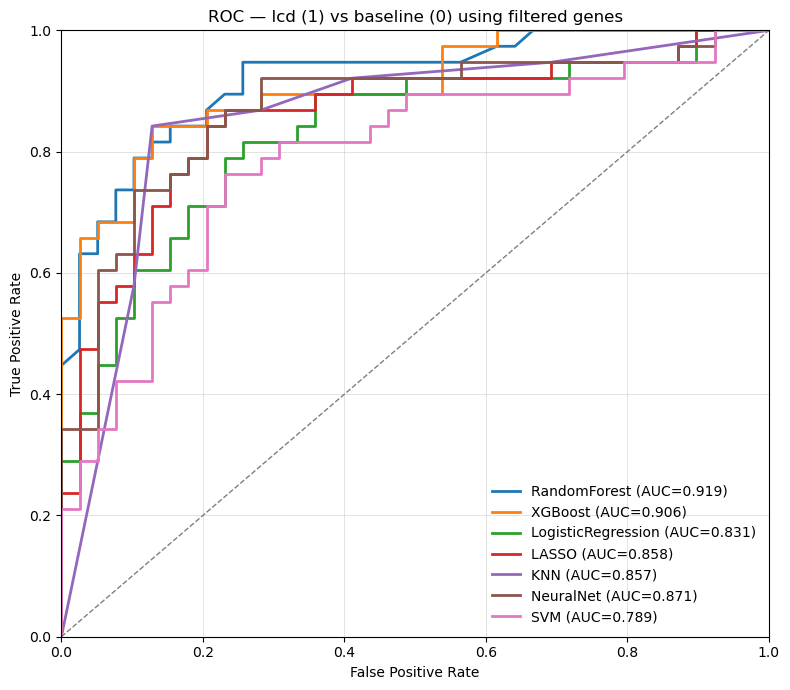

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ----- features: filtered genes only -----
genes = (
    pd.Index(filtered_res.index)
    .astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
)
nc = norm_counts.copy()
nc.index = nc.index.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
X = nc.loc[genes.intersection(nc.index)].T  # samples x genes

# ----- labels: binarize for XGBoost (lcd=1, baseline=0) -----
y_str = metadata.loc[X.index, "condition"]
y = (y_str == "lcd").astype(int)  # 1=lcd (positive class), 0=baseline

# ----- split -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ----- models -----
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42),
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "LASSO": make_pipeline(StandardScaler(), LogisticRegression(penalty="l1", solver="saga", max_iter=5000)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "NeuralNet": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="linear", probability=True, random_state=42)),
}

# ----- ROC plot -----
plt.figure(figsize=(8,7))
for name, clf in models.items():
    clf.fit(X_train, y_train)
    # get positive-class scores
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X_test)[:, 1]
    else:  # some pipelines wrap SVC; use decision_function then min-max to [0,1]
        scores = clf.decision_function(X_test)
        proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    fpr, tpr, _ = roc_curve(y_test, proba, pos_label=1)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1], [0,1], linestyle="--", lw=1)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — lcd (1) vs baseline (0) using filtered genes")
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


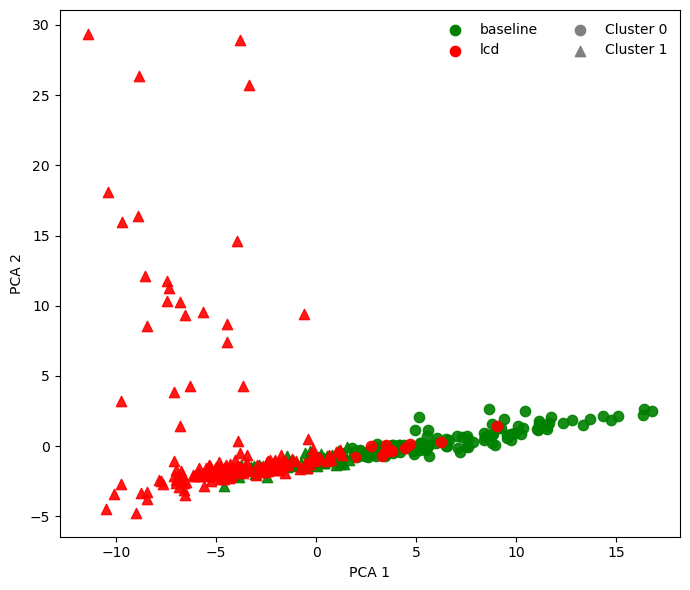

In [15]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

genes = pd.Index(filtered_res.index).astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
nc = norm_counts.copy()
nc.index = nc.index.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
X = nc.loc[genes.intersection(nc.index)].T
y_cls = metadata.loc[X.index, "condition"]

Z = StandardScaler().fit_transform(X)
pca2 = PCA(n_components=2, random_state=42).fit_transform(Z)
clusters = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(pca2)

palette = {"baseline": "green", "lcd": "red"}
markers = {0: "o", 1: "^"}

plt.figure(figsize=(7,6))
for clust in (0,1):
    for cls in ("baseline","lcd"):
        mask = (clusters==clust) & (y_cls.values==cls)
        plt.scatter(pca2[mask,0], pca2[mask,1], c=palette[cls], marker=markers[clust], s=55, alpha=0.9)
for cls,col in palette.items():
    plt.scatter([],[],c=col,marker="o",s=55,label=cls)
for clust,mk in markers.items():
    plt.scatter([],[],c="gray",marker=mk,s=55,label=f"Cluster {clust}")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.legend(loc="best",ncol=2,frameon=False)
plt.tight_layout()
plt.show()


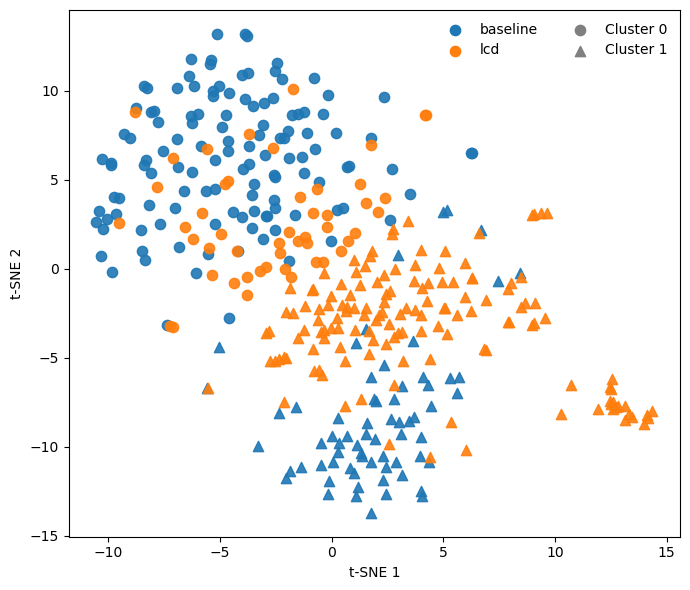

In [16]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

genes = pd.Index(filtered_res.index).astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
nc = norm_counts.copy()
nc.index = nc.index.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
X = nc.loc[genes.intersection(nc.index)].T
y_cls = metadata.loc[X.index, "condition"]

Z = StandardScaler().fit_transform(X)
emb = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42).fit_transform(Z)
clusters = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(emb)

palette = {"baseline": "#1f77b4", "lcd": "#ff7f0e"}
markers = {0: "o", 1: "^"}

plt.figure(figsize=(7,6))
for clust in (0,1):
    for cls in ("baseline","lcd"):
        mask = (clusters==clust) & (y_cls.values==cls)
        plt.scatter(emb[mask,0], emb[mask,1], c=palette[cls], marker=markers[clust], s=55, alpha=0.9)
for cls,col in palette.items():
    plt.scatter([],[],c=col,marker="o",s=55,label=cls)
for clust,mk in markers.items():
    plt.scatter([],[],c="gray",marker=mk,s=55,label=f"Cluster {clust}")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.legend(loc="best", ncol=2, frameon=False)
plt.tight_layout()
plt.show()
